In [1]:
#from shapely.geometry import Point
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium


In [2]:
zips = gpd.read_file('../data/zipcodes.geojson')
print(zips.crs)

EPSG:4326


In [3]:
opioids = pd.read_csv("davidson_zip_opioids.csv")

In [4]:
zips["zip"] = zips["zip"].astype(int)
opioids["zip"] = opioids["zip"].astype(int)

In [5]:

gdf = zips.merge(opioids, on="zip", how="left")
gdf["claims"] = gdf["claims"].fillna(0)


In [6]:
#gdf.plot(column="claims", cmap="OrRd", legend=True, edgecolor="black", figsize=(8,8))
#plt.title("Opioid Claims by ZIP Code — Davidson County, TN", fontsize=8, pad=2)

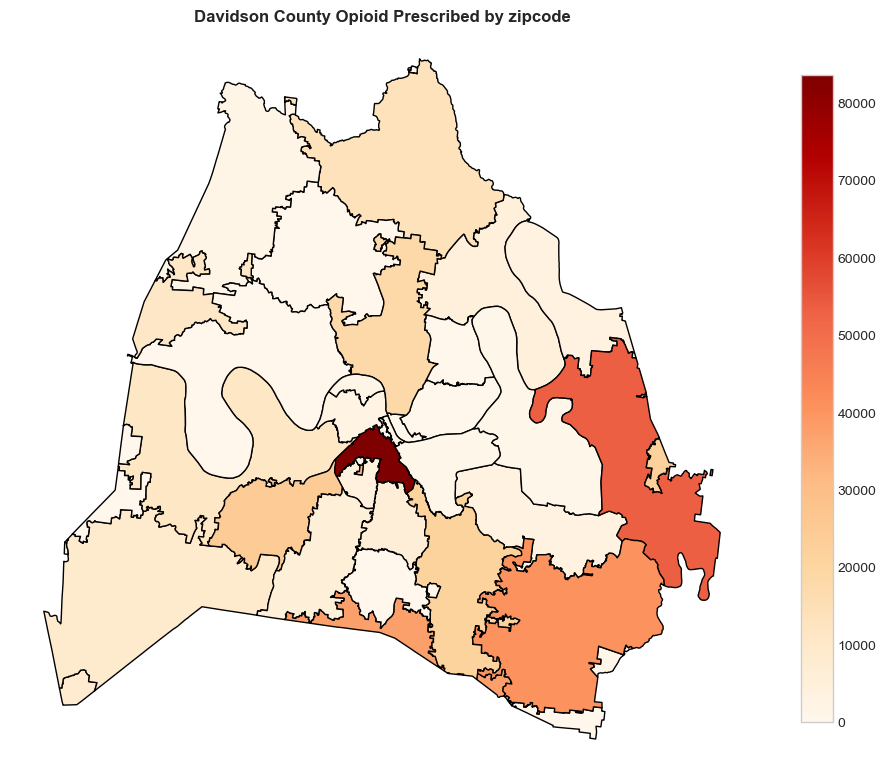

In [7]:
import matplotlib.pyplot as plt
# 
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(column="claims", cmap="OrRd", legend=True, edgecolor="black", figsize=(8,8),ax=ax,legend_kwds={"shrink": 0.7, "orientation": "vertical"})
#  ZIP label
#gdf["centroid"] = gdf.geometry.centroid
##    ax.text(row.centroid.x, row.centroid.y, 
  #           str(row.zip), fontsize=7, ha="center", va="center")
plt.title("Davidson County Opioid Prescribed by zipcode",fontsize=12, pad=1,weight="bold")
ax.set_axis_off()
plt.show()